# Exploratory Data Analysis

## Load Data

In [ ]:
# %pip install pandas numpy matplotlib seaborn statsmodels arch scipy yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import sys
from pathlib import Path
project_root = Path.cwd().parent 
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from src.utils import load_and_preprocess_data
# load data
file_path = '../Case_Study_Data_JNM.csv'
data, returns = load_and_preprocess_data(file_path)
returns.head()

,1,2,3,4,5
date,,,,,
2001-01-31,0.019076,0.007901,-0.026237,0.028615,0.013489
2001-02-28,-0.088422,0.011679,0.007326,-0.132633,-0.038372
2001-03-31,-0.068116,0.003612,-0.035045,-0.102174,-0.032252
2001-04-30,0.071123,-0.011987,0.021212,0.106685,0.029568
2001-05-31,-0.013119,0.003680,0.011772,-0.019678,-0.004719


In [3]:
# plotting settings
primary_color = '#00246B'
secondary_color = '#CADCFC'

# global style
sns.set_style("whitegrid")
plt.rcParams['figure.autolayout'] = True
custom_palette = sns.blend_palette([primary_color, secondary_color], n_colors=5)
sns.set_palette(custom_palette)
line_styles = ['-', '--', '-.', ':', '-']

<!-- ## 2. Plot Time Series -$\to$

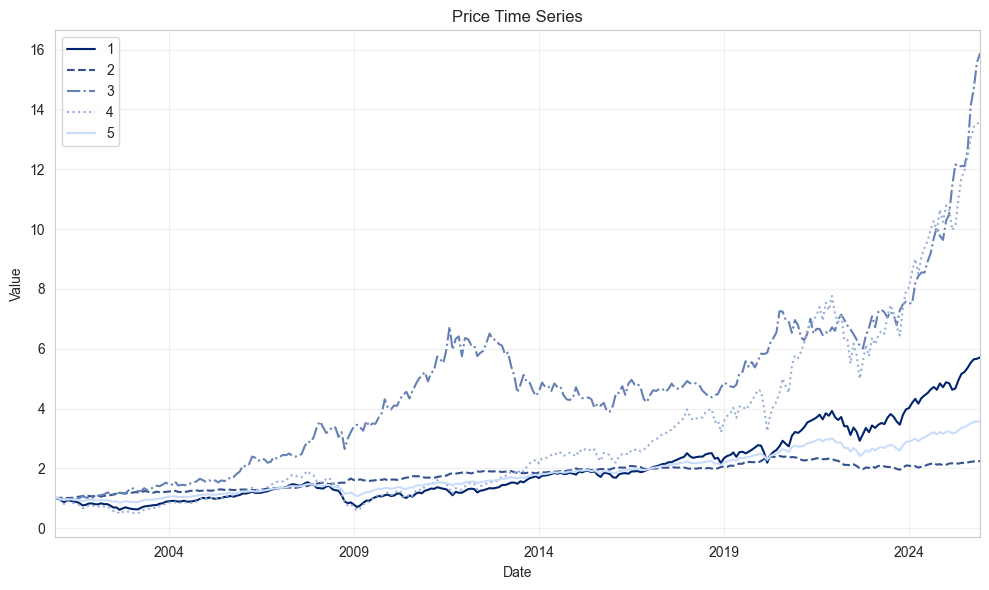

In [4]:
# plot time series of prices
data.plot(figsize=(10, 6), title='Price Time Series', style=line_styles)
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

**Observations (Price Data):**
- **Different Trends:** Asset 3 and 4 exponential growth $\to$ could be equities or gold. 2 is stable $\to$ could be fixed income instrument. 1 and 5 with slight upward trend.
- **Crisis Correlation:** simultaneous drawdowns during 2008 (Global Financial Crisis) and 2020 (COVID-19) $\to$ tail dependence.
- periods of low vs. high trend (e.g., after 2023 acceleration for Asset 3)

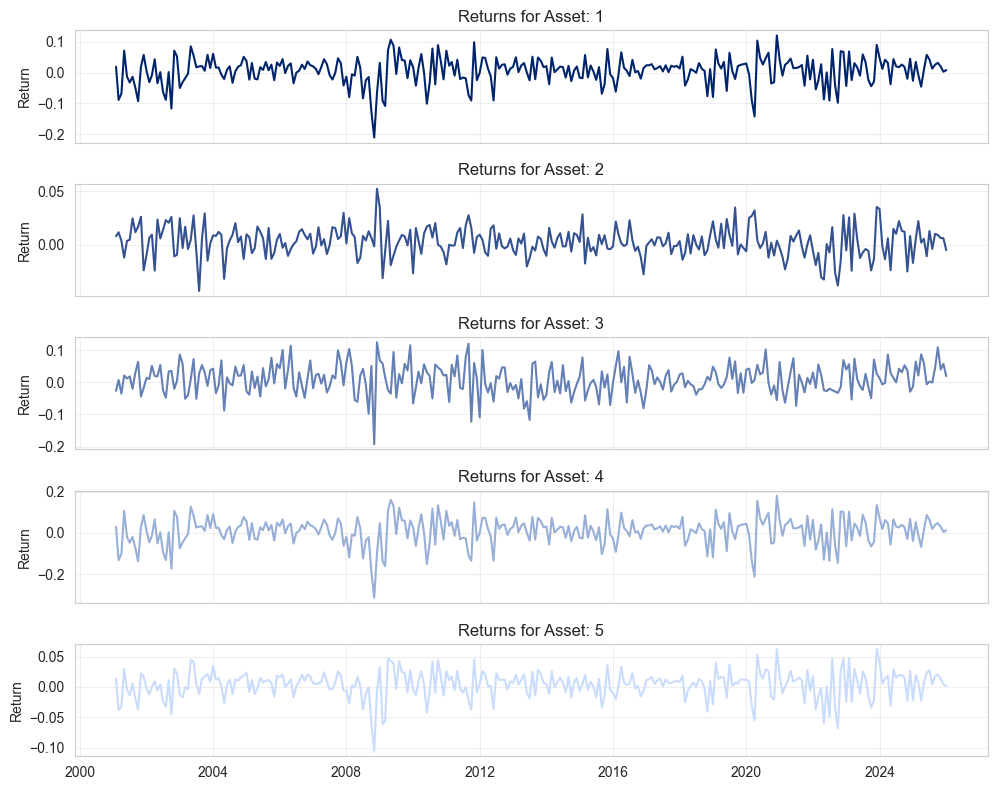

In [ ]:
# plot time series of returns
fig, axes = plt.subplots(len(returns.columns), 1, figsize=(10, 8), sharex=True)
for i, col in enumerate(returns.columns):
    axes[i].plot(returns[col], color=custom_palette[i])
    axes[i].set_title(f'Returns for Asset: {col}')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylabel('Return')

plt.tight_layout()
plt.show()

**Observations (Return Data):**
- **Heteroskedasticity:**  volatility clustering is visible (e.g., 2008, 2020) $\to$ large changes follow large changes
- Asset 4: widest return spread (highest risk), Asset 2 is nearly flat (low risk)
- **Mean Reversion:** stable mean (near zero) $\to$ stationarity

## Histograms and QQ-Plots

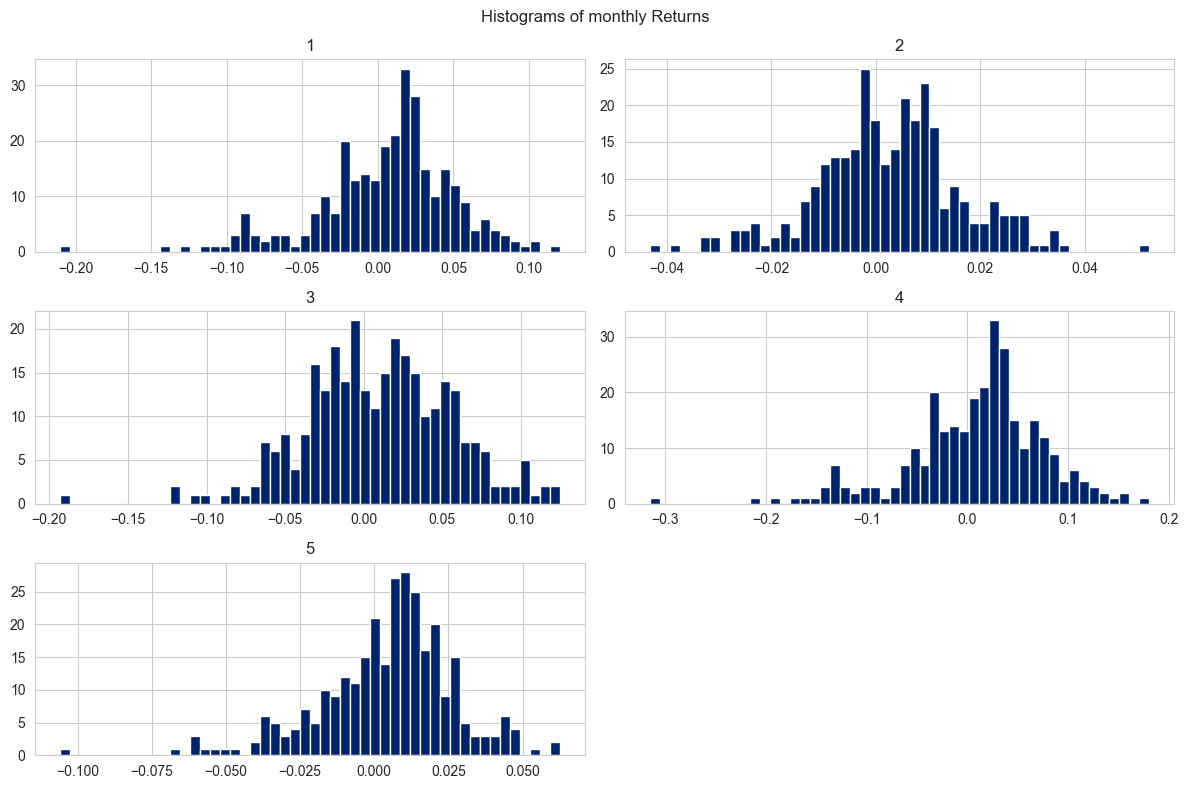

In [ ]:
# plot histograms
returns.hist(bins=50, figsize=(12, 8))
plt.suptitle('Histograms of monthly Returns')
plt.show()

**Observations (Distribution):**
- **Roughly normally distributed**
- **Fat Tails:** Extreme values (e.g., Asset 4 < -0.10) occur frequently $\to$ fat tails
- **Peak at Mean:** concentration of returns around mean (peakedness)
- **Skewness:** negative skew visible in equity-like (4+5, maybe also in 1) (longer left tails) $\to$ crashes are more violent than rallies

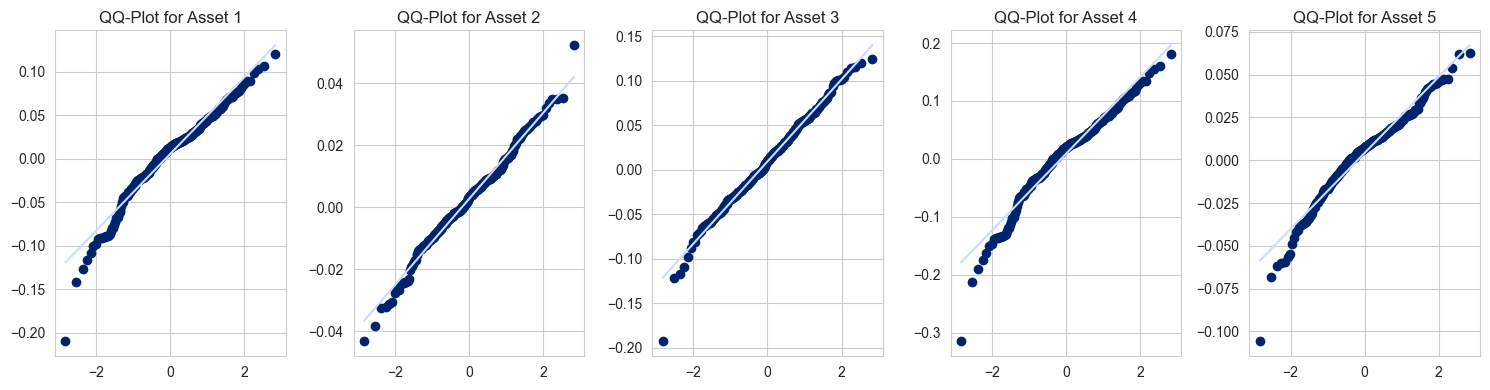

In [ ]:
# plot qq-plots
n_assets = len(returns.columns)
fig, axes = plt.subplots(1, n_assets, figsize=(3 * n_assets, 4))
for i, col in enumerate(returns.columns):
    (osm, osr), (slope, intercept, r) = stats.probplot(returns[col].dropna(), dist="norm")
    axes[i].scatter(osm, osr, color=primary_color)
    axes[i].plot(osm, slope * osm + intercept, color=secondary_color)
    axes[i].set_title(f'QQ-Plot for Asset {col}')

plt.tight_layout()
plt.show()

**Observations:**
- **Fat Tails:** blue Dots diverge from red line at the ends (apart from 2+3)
- **Conclusion:** Extreme events are more frequent than Normal distribution predicts.

## Summary Statistics

In [ ]:
summary_stats = returns.describe().T
summary_stats['skew'] = returns.skew()
summary_stats['kurt'] = returns.kurt()
summary_stats

,count,mean,std,min,25%,50%,75%,max,skew,kurt
1,300.0,0.005808,0.044849,-0.210230,-0.018610,0.012920,0.031593,0.120323,-0.844172,1.990387
2,300.0,0.002685,0.013884,-0.043298,-0.005416,0.003132,0.010371,0.052379,-0.079386,0.736687
3,300.0,0.009216,0.046157,-0.193104,-0.020889,0.010236,0.039829,0.124723,-0.249423,0.858606
4,300.0,0.008712,0.067274,-0.315344,-0.027915,0.019380,0.047390,0.180484,-0.844172,1.990387
5,300.0,0.004246,0.022588,-0.105844,-0.006945,0.007397,0.017474,0.062519,-0.808892,2.178874


**Observations (Summary Stats):**
- **Risk-Return Trade-off:** Asset 4 has highest mean (0.011) and highest volatility (0.067) $\to$ High Risk/High Reward, Asset 2 is the most stable.
- **Negative Skewness:** All assets have negative skew (especially Asset 5 at -0.69) $\to$ Downside crashes are more extreme than upside rallies
- **Excess Kurtosis:** Positive kurtosis across the board (Assets 1 & 5 are highest) $\to$ fat tails
- **Modeling Implication:** Gaussian (Normal) assumption is insufficient $\to$ models must account for skewness and heavy tails (e.g., Student-t distribution)

## Autocorrelation Analysis

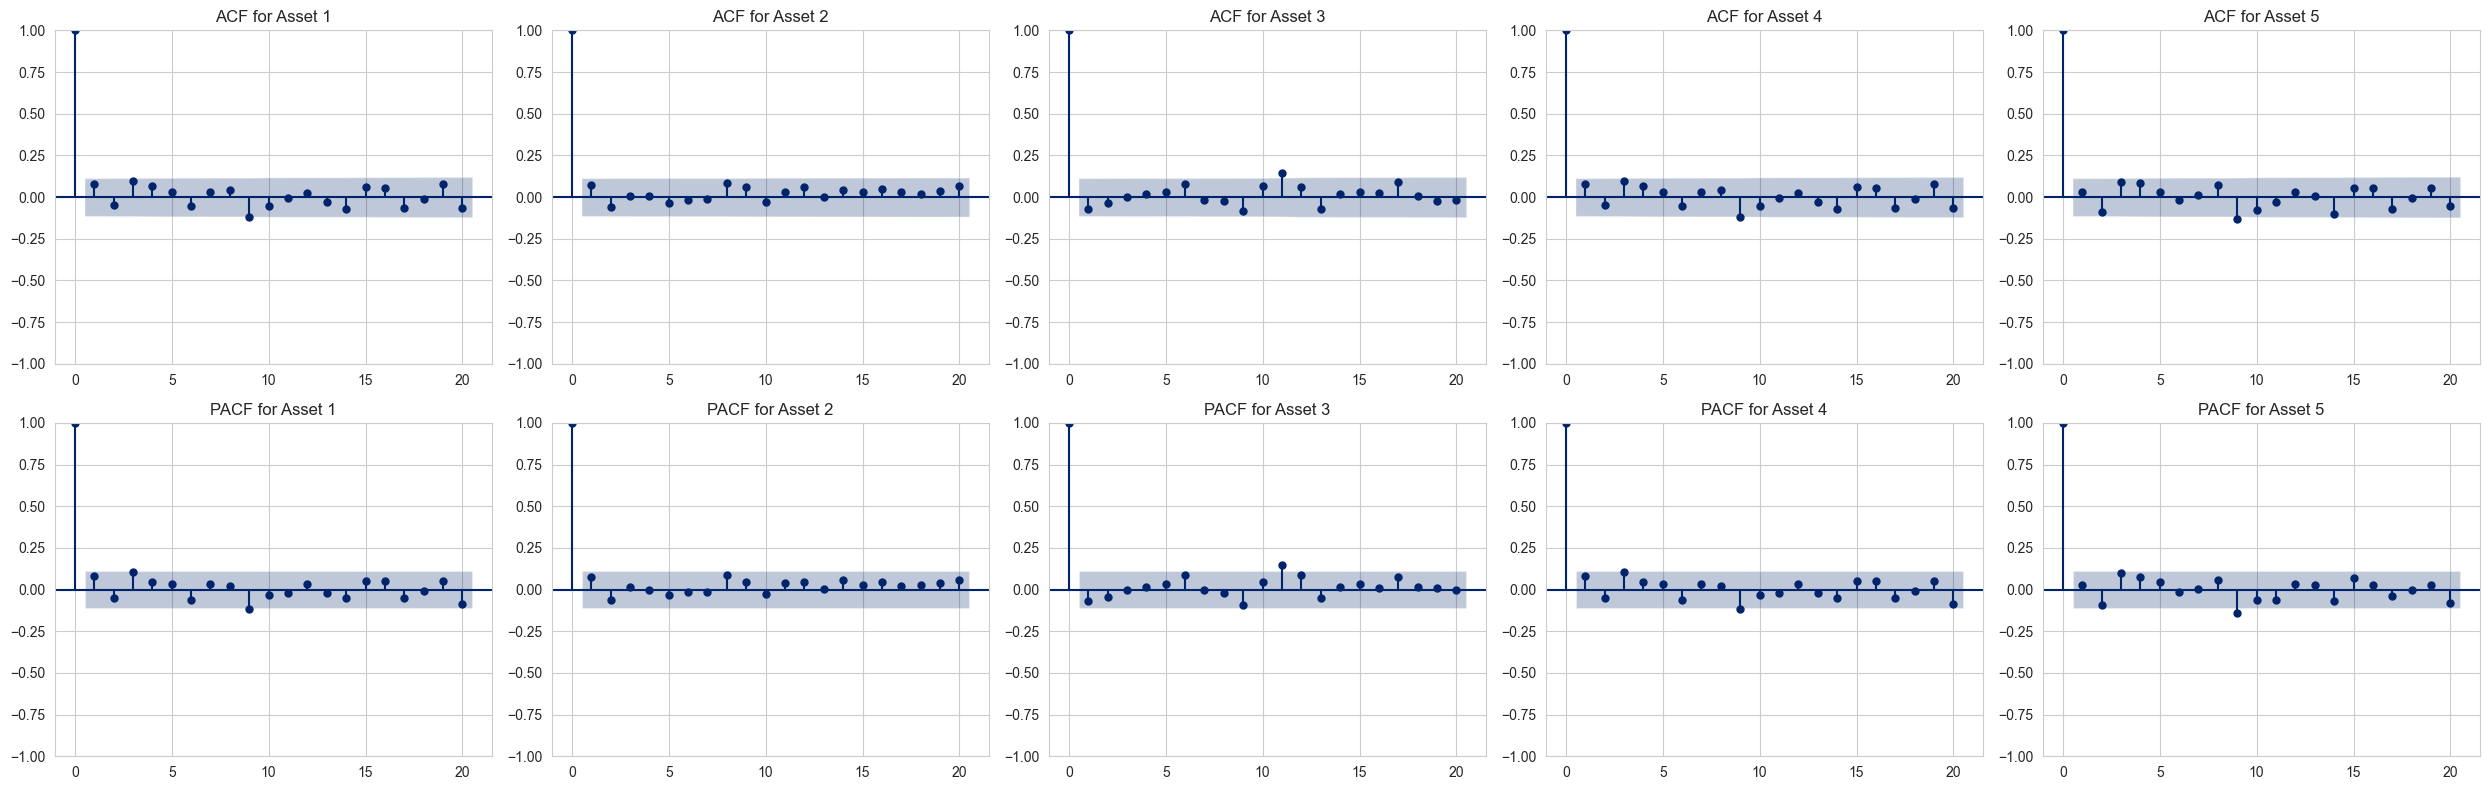

In [ ]:
# plot acf and pacf for returns
fig, axes = plt.subplots(2, len(returns.columns), figsize=(5*len(returns.columns), 8))
for i, col in enumerate(returns.columns):
    plot_acf(returns[col], ax=axes[0, i], title=f'ACF for Asset {col}', lags=20)
    plot_pacf(returns[col], ax=axes[1, i], title=f'PACF for Asset {col}', lags=20)

plt.tight_layout()
plt.show()

**Observations:**
- **No Serial Correlation:** ACF & PACF coefficients mostly stay within the ci
- **Random Walk:** Past returns dont significantly predict future returns

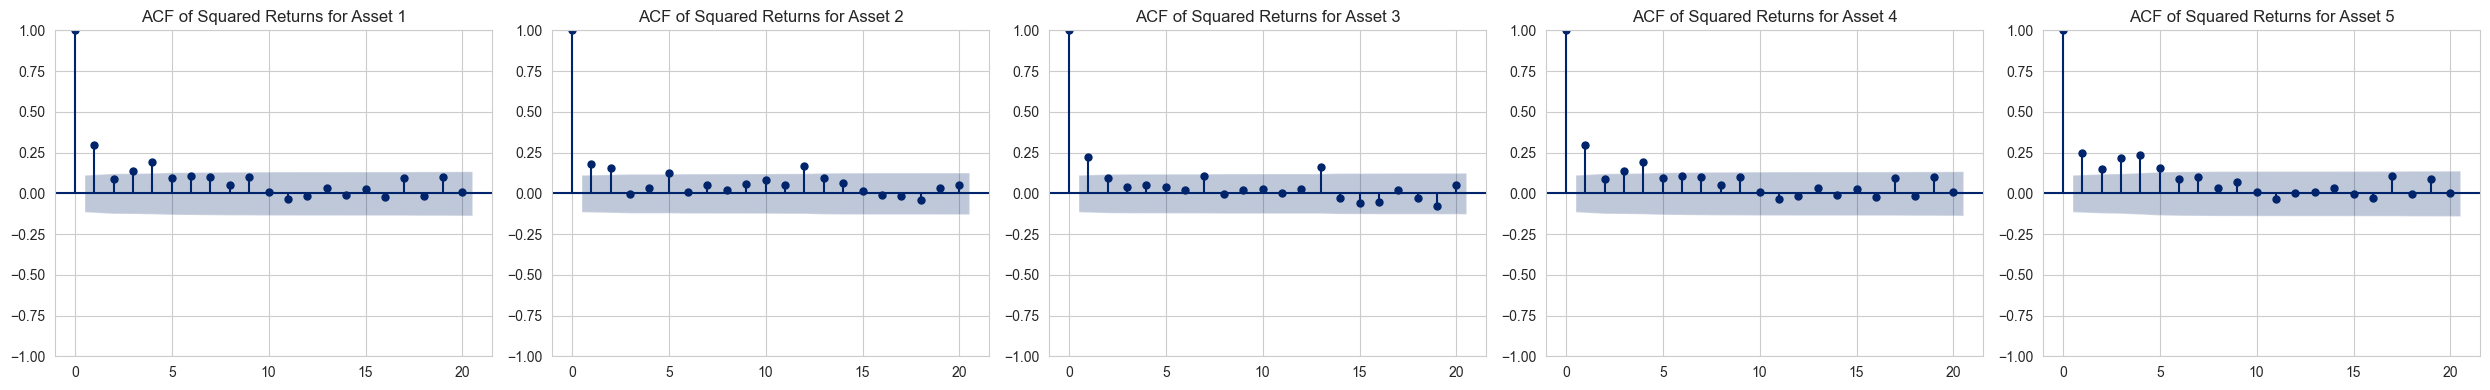

In [ ]:
# plot acf for squared returns (volatility clustering)
fig, axes = plt.subplots(1, len(returns.columns), figsize=(5*len(returns.columns), 4))
for i, col in enumerate(returns.columns):
    plot_acf(returns[col]**2, ax=axes[i], title=f'ACF of Squared Returns for Asset {col}', lags=20)

plt.tight_layout()
plt.show()

**Observations (Squared Returns):**
- **Volatility Clustering:** Significant positive spikes at Lag 1 and beyond (especially Assets 1, 4, and 5).
- **Persistence:** correlation decays slowly $\to$ high volatility periods persist over time $\to$ **GARCH(1,1)** model

## Correlation

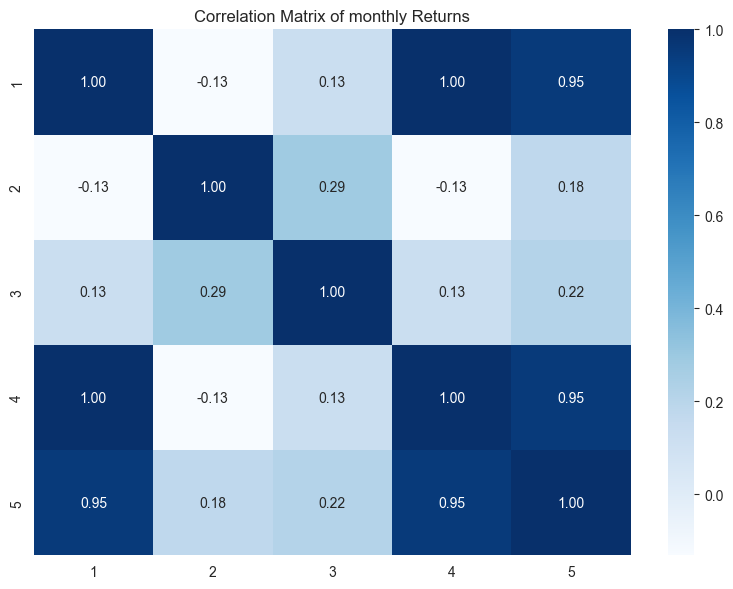

In [ ]:
# calculate correlation matrix
correlation_matrix = returns.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix of monthly Returns')
plt.show()

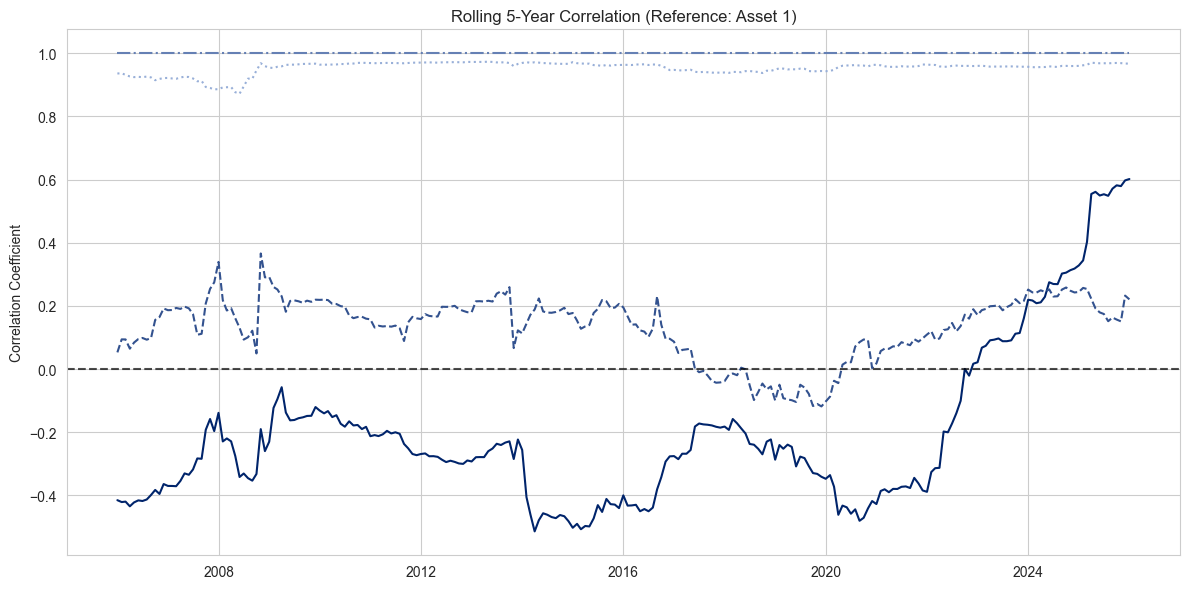

In [ ]:
# rolling correlation of Asset 1 vs All Others (5year window)
plt.figure(figsize=(12, 6))
other_assets = [c for c in returns.columns if c != '1']
for j, col in enumerate(other_assets):
    roll_corr = returns['1'].rolling(window=60).corr(returns[col])
    plt.plot(roll_corr.index, roll_corr.values,
             label=f'Asset 1 vs Asset {col}',
             color=custom_palette[j % len(custom_palette)],
             linestyle=line_styles[j % len(line_styles)])

plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Rolling 5-Year Correlation (Reference: Asset 1)')
plt.ylabel('Correlation Coefficient')
plt.show()

**Observations:**
- **Perfect Correlation:** Assets **1, 4** have perfect correlation $\to$  same asset  (equities), perhaps 4 is some leveraged (1.5x) version of 1 (e.g. ETF)
- **High Correlation:** **1, 4** have very high correlation with **5** $\to$ likely same asset  class (also equities)
- **Asset 2:** Low to Negative correlation (-0.13) with equities $\to$ acts as hedge (perhaps Bonds) $\to$ regime dependence: neg correlation in low inflation era, positive correlation since inflation crisis in 2022.
- **Asset 3:** Low positive correlation with equity cluster $\to$ true diversifier and massive rally after 2022 $\to$ likely gold
- **Modeling Implication:** dependency between 1, 4, and 5 must be preserved $\to$ **Student-t Copula** is ideal here to capture both linear correlation and the joint tail risks (crashes happening together lke GFC)

In [ ]:
leverage_factor = returns['4'] / returns['1']
print(np.mean(leverage_factor))

1.499999999999991


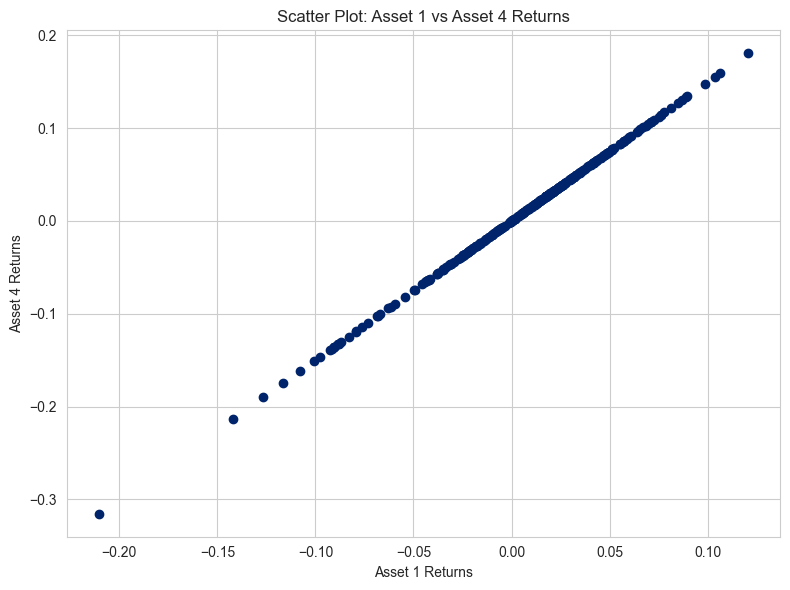

In [ ]:
# relationship between asset 1 and 4
plt.figure(figsize=(8, 6))
plt.scatter(returns['1'], returns['4'])
plt.title('Scatter Plot: Asset 1 vs Asset 4 Returns')
plt.xlabel('Asset 1 Returns')
plt.ylabel('Asset 4 Returns')
plt.show()

[*********************100%***********************]  1 of 1 completed


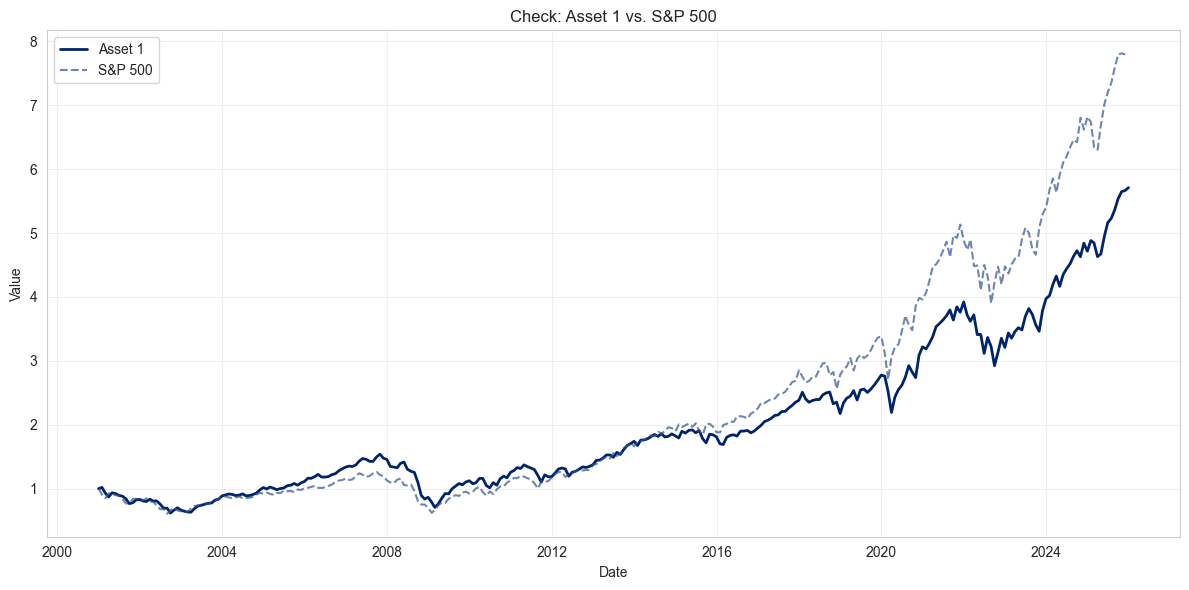

In [25]:
import yfinance as yf

# download S&P 500 data from Yahoo finance
sp500 = yf.download('SPY', start='2000-12-31', end='2025-12-31', interval='1mo', auto_adjust=False)['Adj Close']
sp500_normalized = sp500 / sp500.iloc[0]

# comparison between Asset 1 and S&P 500
plt.figure(figsize=(12, 6))
data.index = pd.to_datetime(data.index)
plt.plot(data.index, data['1'], label='Asset 1', linewidth=2)
plt.plot(sp500_normalized.index, sp500_normalized, label='S&P 500', linestyle='--', alpha=0.7)
plt.title('Check: Asset 1 vs. S&P 500')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.tight_layout()
plt.show()

Asset Types
- 1: High-Growth Equity -> possibly related to S&P500
- 2: Bond
- 3: Gold
- 4: High-Growth Equity leveraged by 1.5x
- 5: Medium-Growth Equity


## Tail Dependence

<Figure size 800x800 with 0 Axes>

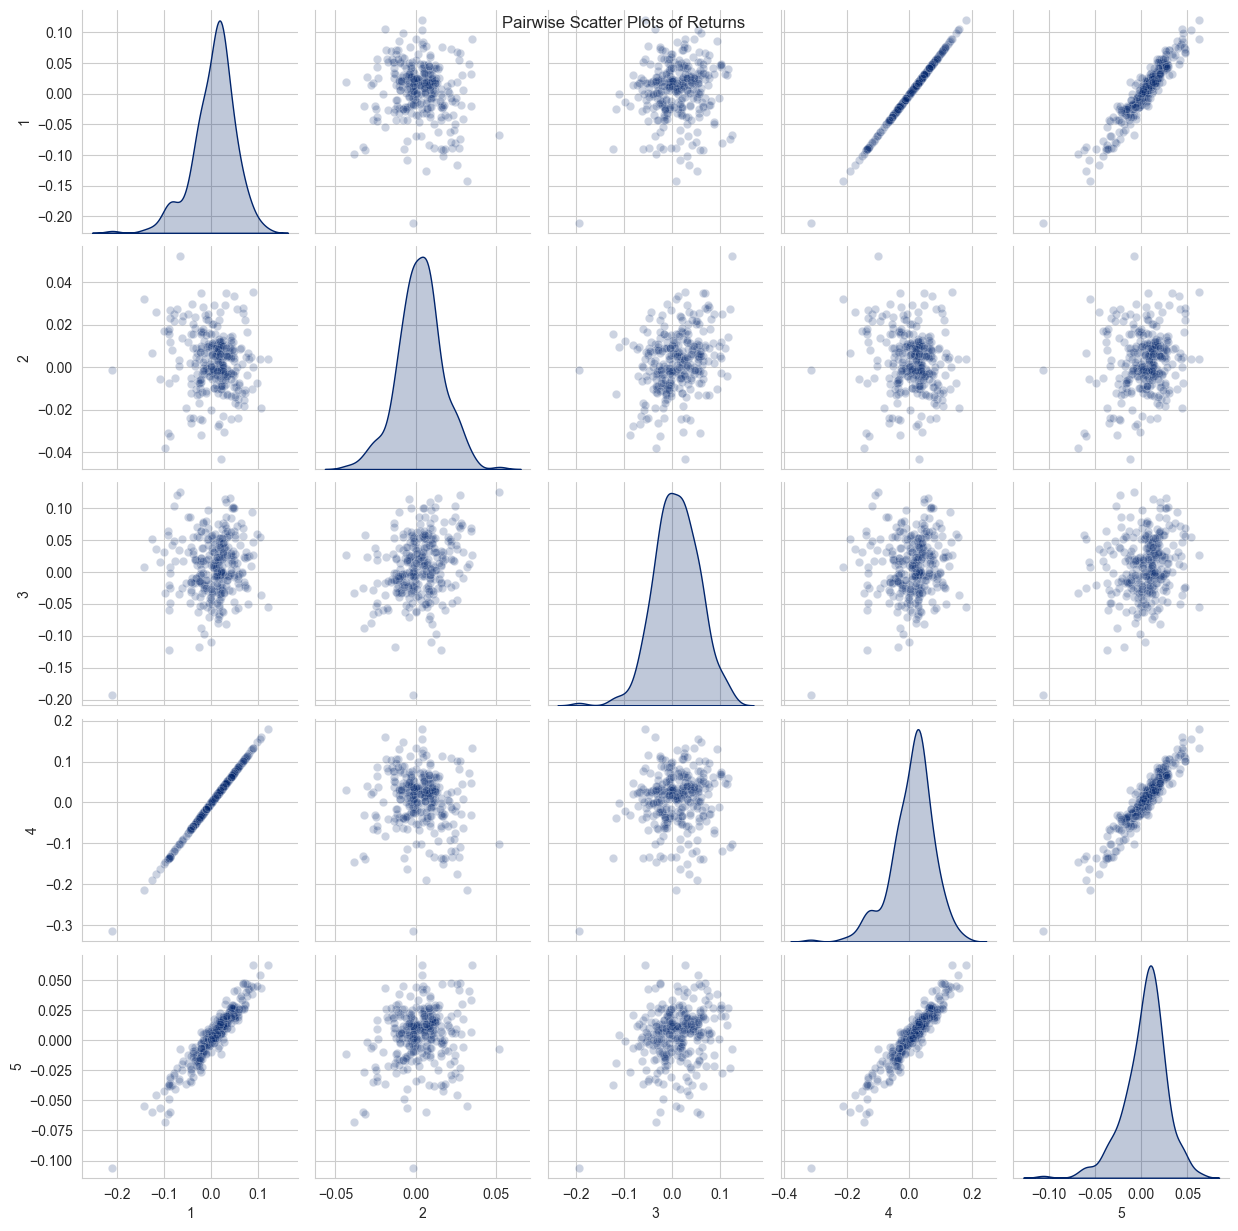

In [ ]:
plt.figure(figsize=(8, 8))
sns.pairplot(returns, diag_kind='kde', plot_kws={'alpha': 0.2})
plt.suptitle('Pairwise Scatter Plots of Returns')
plt.show()

**Observations (Tail Dependence):**
- **Symmetric Dependence:** scatter plots show similar patterns of correlation for both extreme downside and upside events
- **Equity Behavior:** Assets 1, 4, and 5 move together strongly in both tails -> when one crashes, the others crash
- **Bond Behavior:** Asset 2 shows very little correlation with the equity cluster during tail events -> diversifier, but could be dependent on inflationary regime
- **Gold Behavior:** Asset 3 also shows low correlation with equities in tail events -> diversifier